# Tarea 2 — Victor Vargas & Leonardo Zeledon
### Universidad Cenfotec — Aprendizaje Automático
### Scikit-Learn | Sin PySpark

**Datasets:**
- Parte I: Heart Disease Dataset (clasificación binaria)
- Parte II: Mall Customers Dataset (clustering)

In [ ]:
# ── Instalación (Google Colab) ────────────────────────────────────────────────
# !pip install scikit-learn matplotlib seaborn scipy pandas numpy -q

import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# ── Sklearn: preprocesamiento ─────────────────────────────────────────────────
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)

# ── Sklearn: clasificación ────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ── Sklearn: clustering ───────────────────────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Sklearn: métricas ─────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)
print('Entorno listo.')

Entorno listo.


## 📋 Instrucciones

Completa todas las celdas marcadas con `# TODO` (31 ítems).

**Reglas:** sklearn para todo | sin PySpark | random_state=42 en todos los modelos | `_true_cluster` solo al final | notebook ejecutado sin errores.

**Entrega:** notebook ejecutado (.ipynb) + informe escrito (.pdf).

---

## Restricciones y Buenas Prácticas

⚠ Restricciones obligatorias
- Todo debe realizarse con Python estándar y Scikit-Learn.
- La columna _true_cluster NO debe usarse durante el clustering (solo validación final).
- El notebook debe ejecutarse sin errores de principio a fin antes de la entrega.
- Cada celda de código debe tener al menos un comentario explicativo.
- No usar CrossValidator para K-Fold — usar cross_val_score directamente.

✅ Buenas prácticas evaluadas
- Usar Pipeline de sklearn para encadenar preprocesamiento y modelado.
- Fijar random_state en todos los modelos para reproducibilidad.
- Documentar cada decisión de preprocesamiento con su impacto cuantificado.
- Nombrar variables de forma descriptiva y consistente en todo el notebook.
- Incluir títulos descriptivos en todos los gráficos.

## 0.2. Generar / cargar los datasets

Si tienes los CSV, descomenta la carga. Si no, el bloque siguiente los genera automáticamente.

URL: https://archive.ics.uci.edu/dataset/45/heart+disease
URL: https://www.kaggle.com/datasets/shwetabh123/mall-customers

In [ ]:
import pandas as pd
import os
# ── Opción A: cargar desde archivo (descomenta si subes el CSV) ───────────────
from google.colab import files
#uploaded = files.upload()
#df_heart_raw = pd.read_csv('heart_disease.csv')
#df_mall_raw  = pd.read_csv('mall_customers.csv')

#print(f'Heart Disease: {df_heart_raw.shape} | target: {df_heart_raw.target.value_counts().to_dict()}')
#print(f'Mall Customers: {df_mall_raw.shape}')

#Carga el dataset si existe
if os.path.exists('heart_disease.csv'):
    df_heart_raw = pd.read_csv('heart_disease.csv')

    #Ajusta el documento .data de Cleveland original proveido por el profesor a la expectativa de datos del enunciado
    if not set(df_heart_raw['target'].dropna().unique()).issubset({0, 1}):
      df_heart_raw['target'] = (df_heart_raw['target'] > 0).astype(int)

    if set(df_heart_raw['cp'].dropna().unique()) == {1.0, 2.0, 3.0, 4.0}:
      df_heart_raw['cp'] = df_heart_raw['cp'] - 1

    if set(df_heart_raw['slope'].dropna().unique()) == {1.0, 2.0, 3.0}:
      df_heart_raw['slope'] = df_heart_raw['slope'] - 1

    if set(df_heart_raw['thal'].dropna().unique()).issubset({3.0, 6.0, 7.0}):
      df_heart_raw['thal'] = df_heart_raw['thal'].map({3.0: 1.0, 6.0: 2.0, 7.0: 3.0})

    print(f'Heart Disease: {df_heart_raw.shape} | target: {df_heart_raw.target.value_counts().to_dict()}')
else:
    print('Heart Disease: heart_disease.csv no encontrado todavía (pendiente para la Parte I).')

# Mall Customers (Parte II) — coloca mall_customers.csv en este directorio, o súbelo en Colab
if os.path.exists('mall_customers.csv'):
    df_mall_raw = pd.read_csv('mall_customers.csv')
    print(f'Mall Customers: {df_mall_raw.shape}')
else:
    print('Mall Customers: mall_customers.csv no encontrado todavía.')




Heart Disease: heart_disease.csv no encontrado todavía (pendiente para la Parte I).
Mall Customers: (200, 5)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# PARTE I — CLASIFICACIÓN: HEART DISEASE

## 1. Carga y exploración inicial

In [ ]:
df_heart = df_heart_raw.copy()
print(f'Filas: {df_heart.shape[0]}  Columnas: {df_heart.shape[1]}')
display(df_heart.head(10))
print('\nTipos de datos:')
print(df_heart.dtypes)
print('\nNulos por columna:')
print(df_heart.isnull().sum())

Filas: 303  Columnas: 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,0.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,2.0,0.0,2.0,0
1,67.0,1.0,3.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,1.0,3.0,1.0,1
2,67.0,1.0,3.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1.0,2.0,3.0,1
3,37.0,1.0,2.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,2.0,0.0,1.0,0
4,41.0,0.0,1.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0.0,0.0,1.0,0
5,56.0,1.0,1.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,0.0,0.0,1.0,0
6,62.0,0.0,3.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,2.0,2.0,1.0,1
7,57.0,0.0,3.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,0.0,0.0,1.0,0
8,63.0,1.0,3.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,1.0,1.0,3.0,1
9,53.0,1.0,3.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,2.0,0.0,3.0,1



Tipos de datos:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Nulos por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


## 2. EDA

In [ ]:
# TODO 2: Calcular estadísticas descriptivas con .describe(include='all').
display(df_heart.describe(include='all').T.round(3))


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.439,9.039,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.680,0.467,0.0,0.0,1.0,1.0,1.0
cp,303.0,2.158,0.960,0.0,2.0,2.0,3.0,3.0
trestbps,303.0,131.690,17.600,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693,51.777,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.149,0.356,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990,0.995,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607,22.875,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.327,0.470,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.040,1.161,0.0,0.0,0.8,1.6,6.2


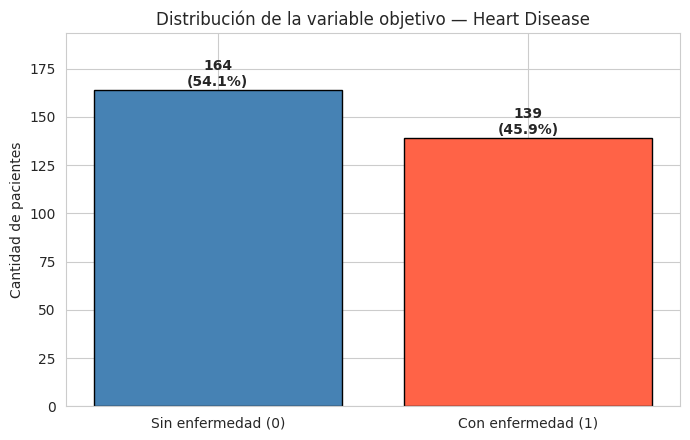

In [ ]:
# TODO 3: Graficar distribución del target con barras y porcentajes.
counts = df_heart['target'].value_counts().sort_index()
labels = ['Sin enfermedad (0)', 'Con enfermedad (1)']

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, counts.values, color=['steelblue', 'tomato'], edgecolor='black')

for bar, value in zip(bars, counts.values):
    pct = 100 * value / len(df_heart)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{value}\n({pct:.1f}%)', ha='center', fontweight='bold')

ax.set_title('Distribución de la variable objetivo — Heart Disease')
ax.set_ylabel('Cantidad de pacientes')
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()

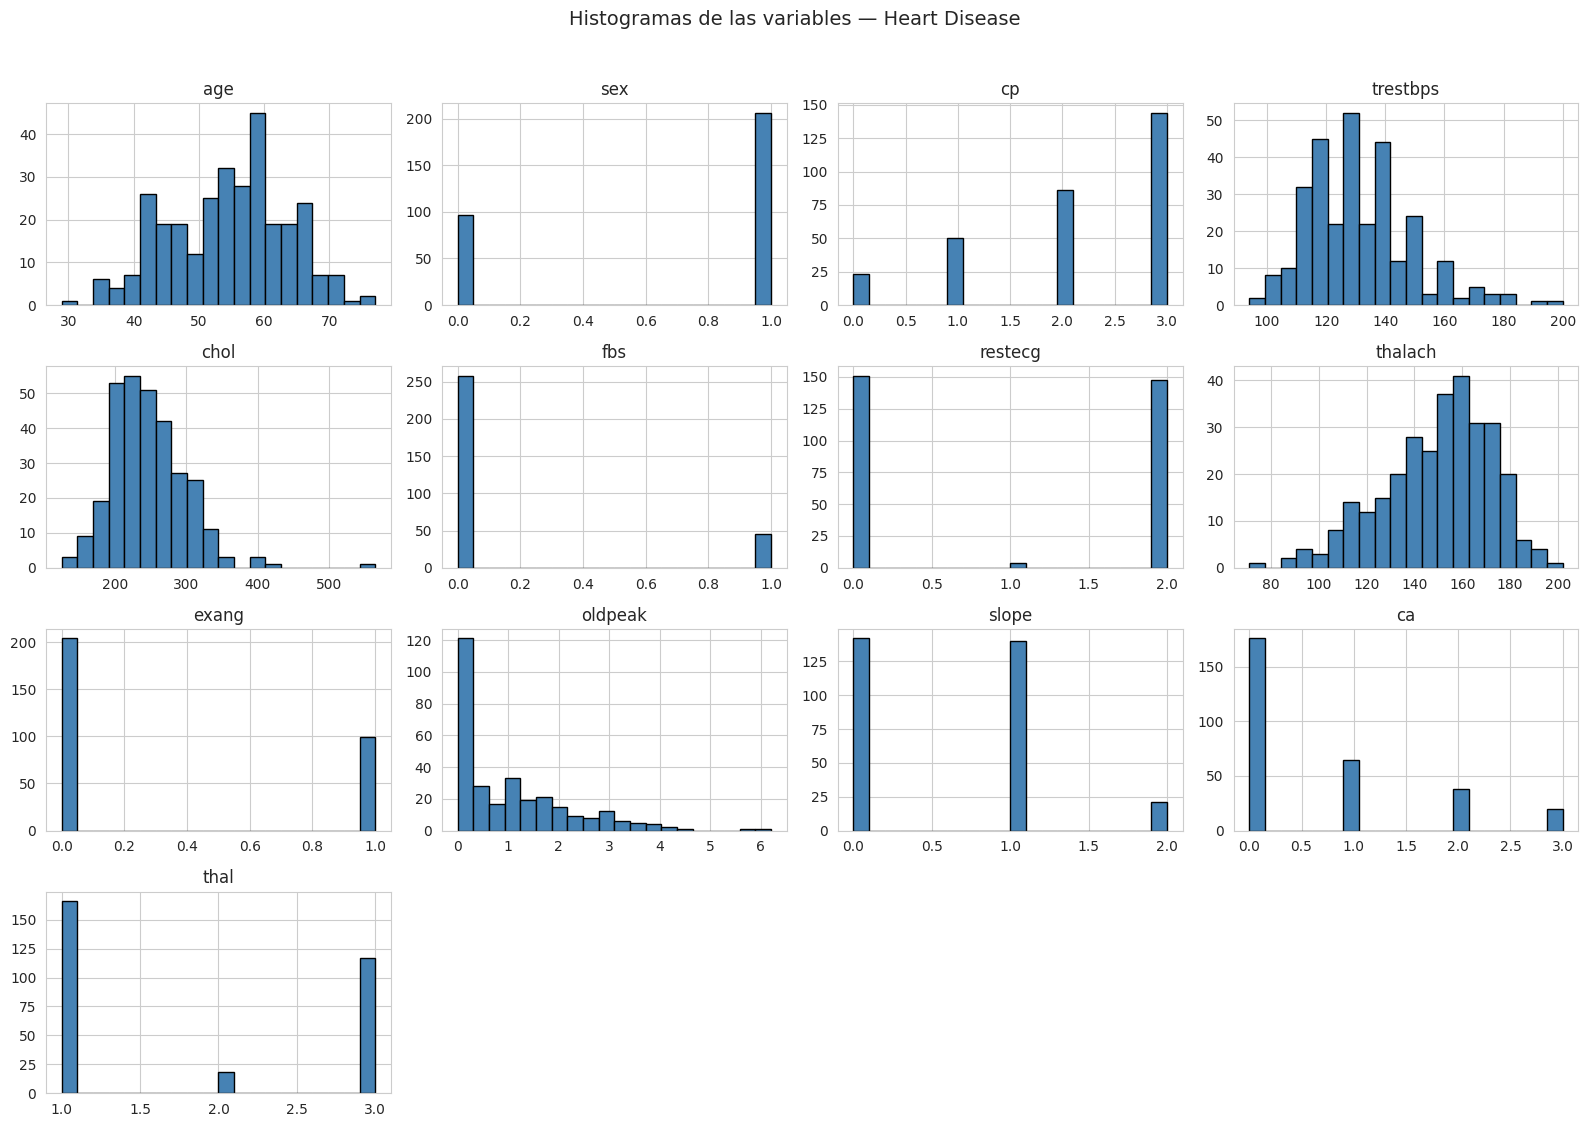

In [ ]:
# TODO 4: Graficar histogramas de todas las variables en una grilla.
# Se excluye target porque ya fue analizado con un gráfico de barras.
hist_cols = [c for c in df_heart.columns if c != 'target']
df_heart[hist_cols].hist(bins=20, figsize=(16, 11), color='steelblue', edgecolor='black')
plt.suptitle('Histogramas de las variables — Heart Disease', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


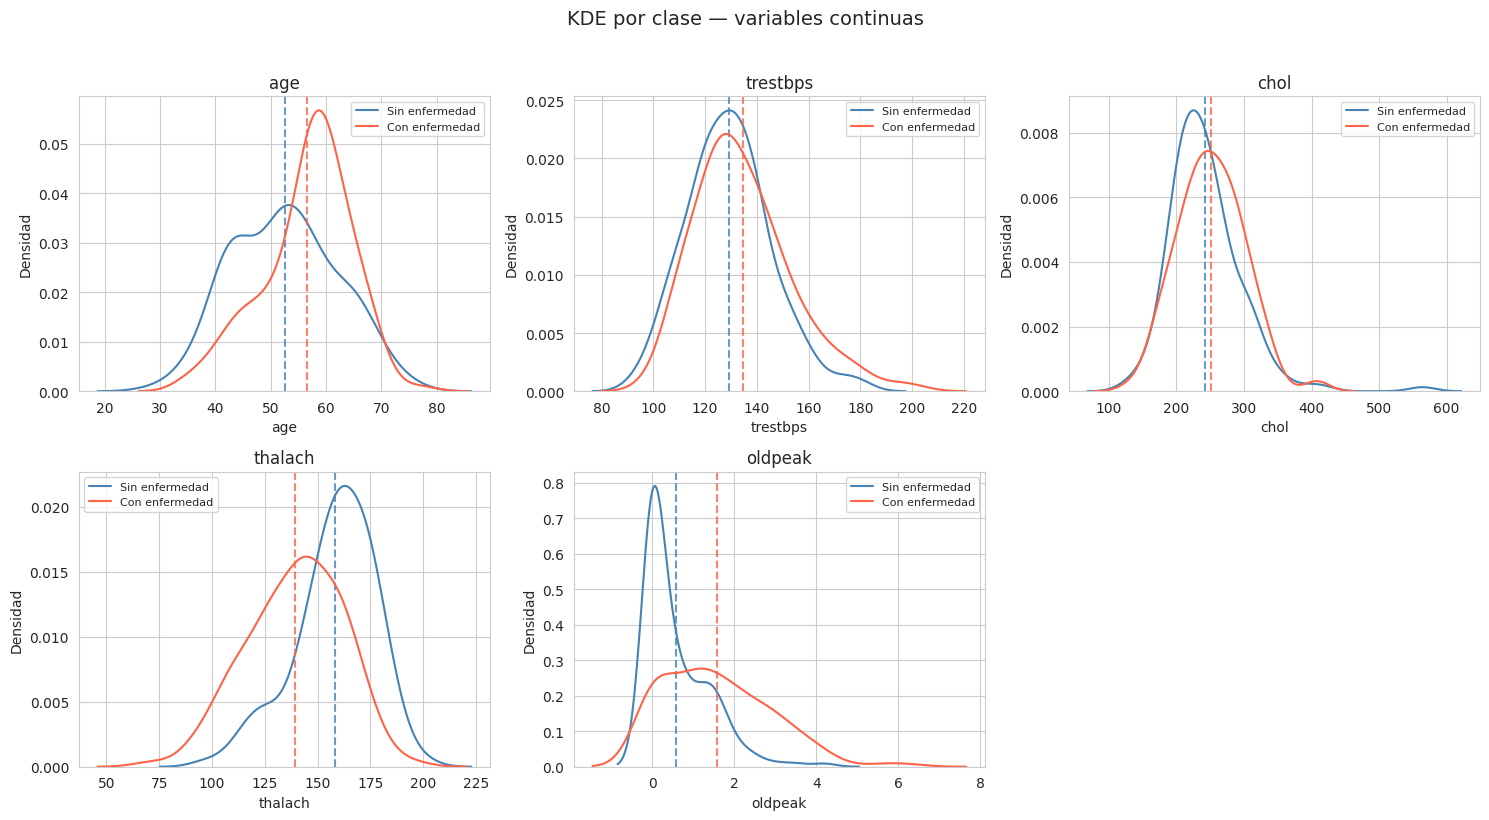

In [ ]:
# TODO 5: KDE por clase (target=0 vs 1) para variables continuas.
# Marcar la media de cada grupo con línea punteada vertical.
CONTINUOUS_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
FEATURE_COLS_ALL = [c for c in df_heart.columns if c != 'target']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, CONTINUOUS_COLS):
    for clase, color, label in [(0, 'steelblue', 'Sin enfermedad'),
                                (1, 'tomato', 'Con enfermedad')]:
        datos = df_heart.loc[df_heart['target'] == clase, col].dropna()
        sns.kdeplot(datos, ax=ax, color=color, label=label)
        ax.axvline(datos.mean(), color=color, linestyle='--', alpha=0.8)
    ax.set_title(col)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

# Ocultar el panel que sobra.
for ax in axes[len(CONTINUOUS_COLS):]:
    ax.axis('off')

plt.suptitle('KDE por clase — variables continuas', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

variable  media_sano  media_enf  d_cohen         efecto
    thal       1.380      2.377   1.2159         Grande
      ca       0.273      1.138   1.0370         Grande
   exang       0.140      0.547   0.9578         Grande
 oldpeak       0.587      1.574   0.9378         Grande
 thalach     158.378    139.259  -0.9181         Grande
      cp       1.793      2.590   0.9109         Grande
   slope       0.409      0.827   0.7213        Mediano
     sex       0.561      0.820   0.5762        Mediano
     age      52.585     56.626   0.4578        Pequeño
 restecg       0.835      1.173   0.3434        Pequeño
trestbps     129.250    134.568   0.3052        Pequeño
    chol     242.640    251.475   0.1710 Insignificante
     fbs       0.140      0.158   0.0505 Insignificante


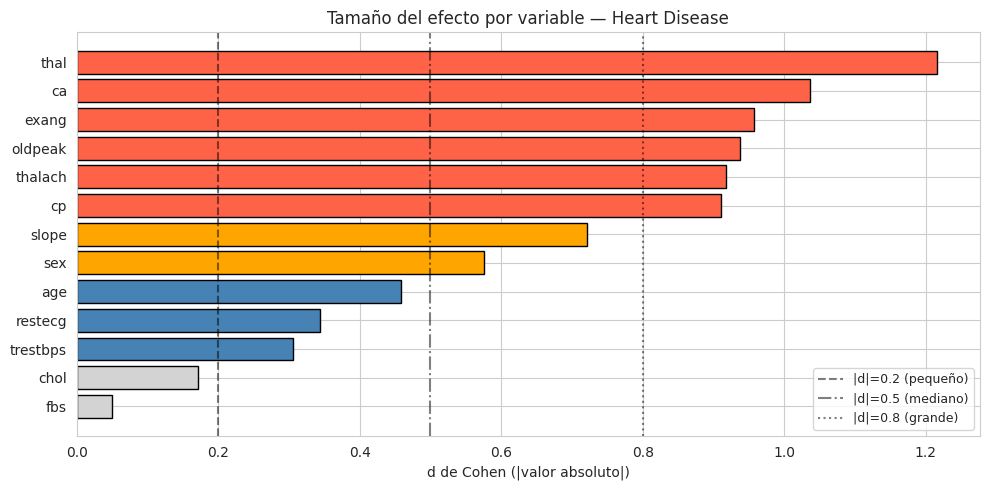

In [ ]:
# d de Cohen
def cohen_d(df, feature_cols, group_col='target'):
    results = []
    for col in feature_cols:
        g0 = df[df[group_col]==0][col].dropna()
        g1 = df[df[group_col]==1][col].dropna()
        n0, n1 = len(g0), len(g1)
        v0, v1 = g0.var(ddof=1), g1.var(ddof=1)
        std_p = np.sqrt(((n1-1)*v1 + (n0-1)*v0) / (n1+n0-2)) if (v0 and v1) else 1
        d = (g1.mean() - g0.mean()) / std_p if std_p else 0
        abs_d = abs(d)
        efecto = 'Grande' if abs_d>=0.8 else ('Mediano' if abs_d>=0.5 else ('Pequeño' if abs_d>=0.2 else 'Insignificante'))
        results.append({'variable':col,'media_sano':round(g0.mean(),3),
                        'media_enf':round(g1.mean(),3),'d_cohen':round(d,4),'efecto':efecto})
    return pd.DataFrame(results).sort_values('d_cohen', key=abs, ascending=False)

cohen_pd = cohen_d(df_heart, FEATURE_COLS_ALL)
print(cohen_pd.to_string(index=False))

colors_d = {'Grande':'tomato','Mediano':'orange','Pequeño':'steelblue','Insignificante':'lightgrey'}
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(cohen_pd['variable'][::-1], cohen_pd['d_cohen'].abs()[::-1],
        color=[colors_d[e] for e in cohen_pd['efecto'][::-1]], edgecolor='black')
for u, ls, lb in [(0.2,'--','pequeño'),(0.5,'-.','mediano'),(0.8,':','grande')]:
    ax.axvline(u, color='black', linestyle=ls, alpha=0.5, label=f'|d|={u} ({lb})')
ax.set_xlabel('d de Cohen (|valor absoluto|)')
ax.set_title('Tamaño del efecto por variable — Heart Disease', fontsize=12)
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

In [ ]:
# TODO 7: Curtosis con .kurtosis(). Clasificar e interpretar.
kurtosis_values = df_heart[FEATURE_COLS_ALL].kurtosis()

kurtosis_rows = []
for col, value in kurtosis_values.items():
    if value > 0.5:
        tipo = 'Leptocúrtica'
        interpretacion = 'colas más pesadas / mayor concentración central'
    elif value < -0.5:
        tipo = 'Platicúrtica'
        interpretacion = 'distribución más aplanada'
    else:
        tipo = 'Aprox. mesocúrtica'
        interpretacion = 'curtosis cercana a la distribución normal'
    kurtosis_rows.append({
        'variable': col,
        'curtosis': round(value, 4),
        'clasificación': tipo,
        'interpretación': interpretacion
    })

kurtosis_df = pd.DataFrame(kurtosis_rows).sort_values('curtosis', ascending=False)
display(kurtosis_df.reset_index(drop=True))


,variable,curtosis,clasificación,interpretación
0,chol,4.4917,Leptocúrtica,colas más pesadas / mayor concentración central
1,fbs,1.9597,Leptocúrtica,colas más pesadas / mayor concentración central
2,oldpeak,1.5758,Leptocúrtica,colas más pesadas / mayor concentración central
3,trestbps,0.8801,Leptocúrtica,colas más pesadas / mayor concentración central
4,ca,0.2593,Aprox. mesocúrtica,curtosis cercana a la distribución normal
5,thalach,-0.0535,Aprox. mesocúrtica,curtosis cercana a la distribución normal
6,cp,-0.4007,Aprox. mesocúrtica,curtosis cercana a la distribución normal
7,age,-0.5234,Platicúrtica,distribución más aplanada
8,slope,-0.6275,Platicúrtica,distribución más aplanada
9,sex,-1.4088,Platicúrtica,distribución más aplanada


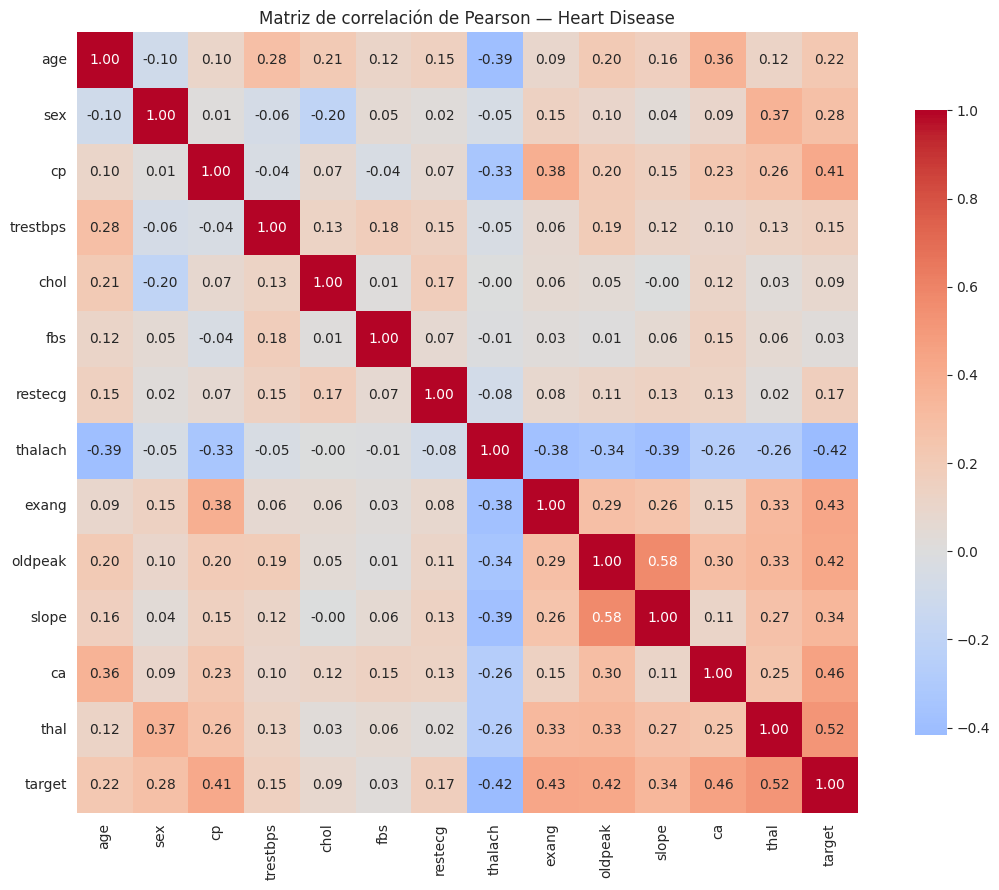


Correlación con target (ordenada por valor absoluto):
thal        0.519
ca          0.460
exang       0.432
oldpeak     0.425
thalach    -0.417
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
Name: target, dtype: float64


In [ ]:
# TODO 8: Mapa de calor de correlaciones de Pearson.
corr = df_heart.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación de Pearson — Heart Disease')
plt.tight_layout()
plt.show()

print('\nCorrelación con target (ordenada por valor absoluto):')
print(corr['target'].drop('target').sort_values(key=abs, ascending=False).round(3))

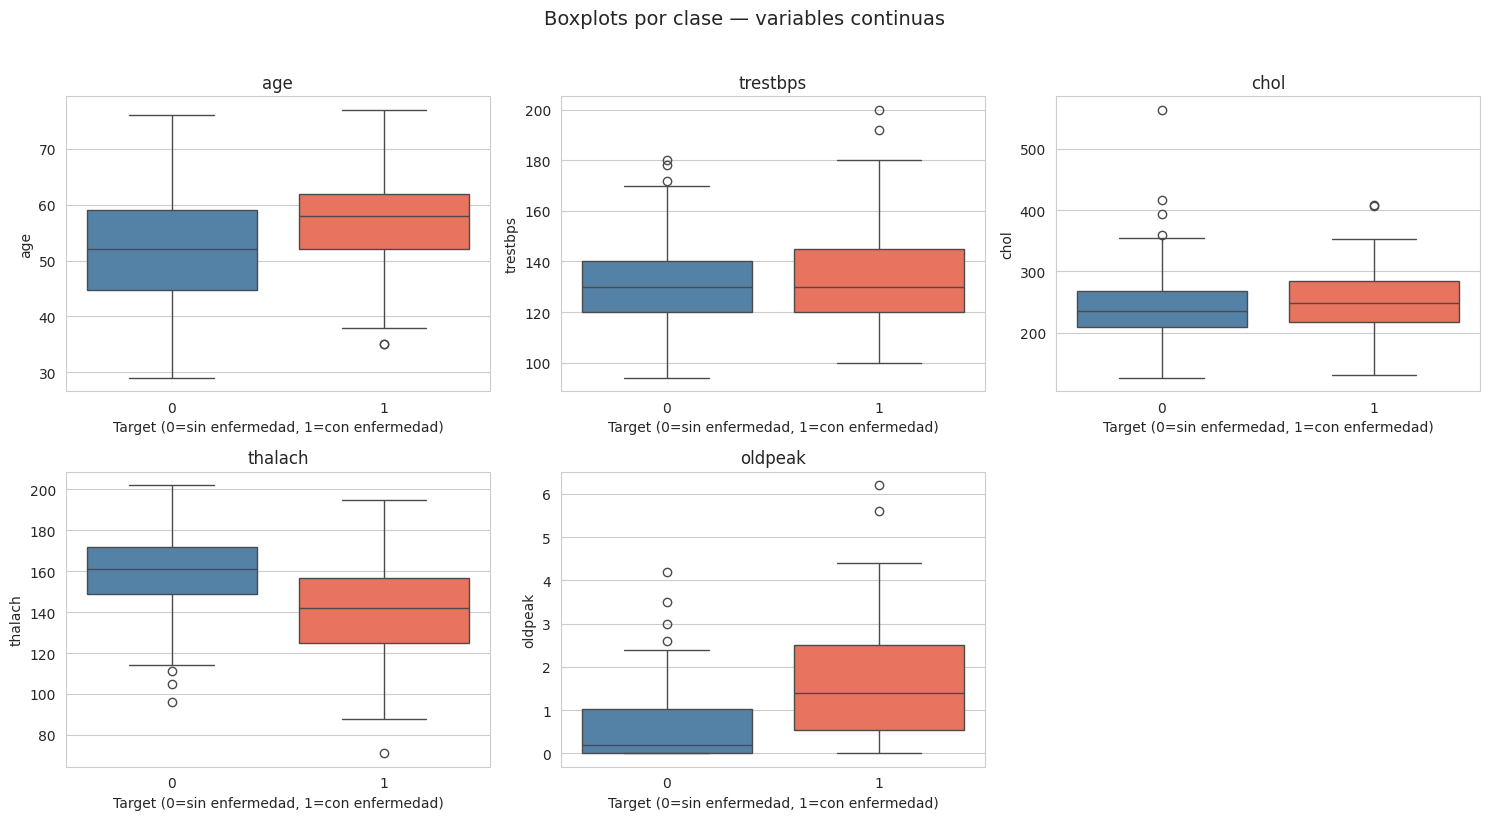

In [ ]:
# TODO 9: Boxplots de variables numéricas por clase.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, CONTINUOUS_COLS):
    sns.boxplot(x='target', y=col, data=df_heart, ax=ax, palette=['steelblue', 'tomato'])
    ax.set_title(col)
    ax.set_xlabel('Target (0=sin enfermedad, 1=con enfermedad)')

for ax in axes[len(CONTINUOUS_COLS):]:
    ax.axis('off')

plt.suptitle('Boxplots por clase — variables continuas', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 3. Tratamiento de valores faltantes

In [ ]:
COLS_MISSING = ['ca', 'thal']

# Estrategia A: imputación con la media (SimpleImputer)
imputer = SimpleImputer(strategy='mean')
df_imputed = df_heart.copy()
df_imputed[COLS_MISSING] = imputer.fit_transform(df_heart[COLS_MISSING])
print(f'Filas tras imputación : {len(df_imputed)} | Nulos restantes: {df_imputed.isnull().sum().sum()}')

# Estrategia B: eliminar filas con nulos
df_dropna = df_heart.dropna(subset=COLS_MISSING)
print(f'Filas tras dropna     : {len(df_dropna)}')
print('\nDecisión: se usa imputación con la media — preserva más datos (303 vs 291).')

Filas tras imputación : 303 | Nulos restantes: 0
Filas tras dropna     : 297

Decisión: se usa imputación con la media — preserva más datos (303 vs 291).


## 4. Detección y manejo de outliers (IQR)

,variable,Q1,Q3,límite inferior,límite superior,n_outliers,porcentaje
0,trestbps,120.0,140.0,90.00,170.00,9,2.97
1,oldpeak,0.0,1.6,-2.40,4.00,5,1.65
2,chol,211.0,275.0,115.00,371.00,5,1.65
3,thalach,133.5,166.0,84.75,214.75,1,0.33
4,age,48.0,61.0,28.50,80.50,0,0.00


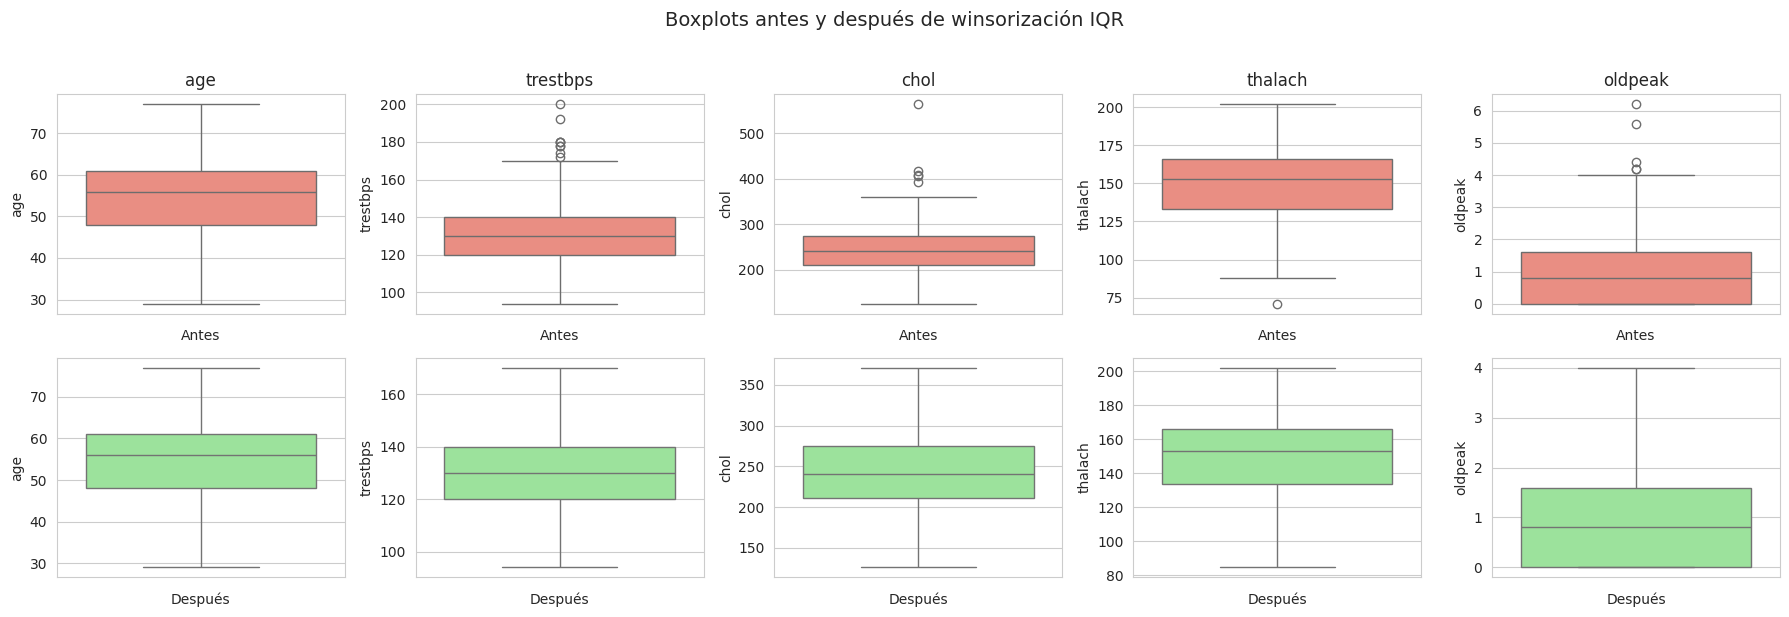

Filas antes: 303 | Filas después: 303
La winsorización conserva las filas y limita únicamente valores continuos fuera del rango IQR.


In [ ]:
# TODO 12: Método IQR con pandas/numpy. Cuantificar outliers. Boxplots antes/después.
def detectar_outliers_iqr(df, columnas):
    resumen = []
    for col in columnas:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        mask = (df[col] < lim_inf) | (df[col] > lim_sup)
        resumen.append({
            'variable': col,
            'Q1': round(q1, 3),
            'Q3': round(q3, 3),
            'límite inferior': round(lim_inf, 3),
            'límite superior': round(lim_sup, 3),
            'n_outliers': int(mask.sum()),
            'porcentaje': round(100 * mask.mean(), 2)
        })
    return pd.DataFrame(resumen)

outliers_df = detectar_outliers_iqr(df_imputed, CONTINUOUS_COLS)
display(outliers_df.sort_values('n_outliers', ascending=False).reset_index(drop=True))

# Winsorización: los valores fuera de los límites IQR se recortan al límite correspondiente.
df_clean = df_imputed.copy()
for col in CONTINUOUS_COLS:
    q1 = df_imputed[col].quantile(0.25)
    q3 = df_imputed[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    df_clean[col] = df_clean[col].clip(lower=lim_inf, upper=lim_sup)

# Comparación visual antes y después del tratamiento.
fig, axes = plt.subplots(2, len(CONTINUOUS_COLS), figsize=(18, 6))
for j, col in enumerate(CONTINUOUS_COLS):
    sns.boxplot(y=df_imputed[col], ax=axes[0, j], color='salmon')
    axes[0, j].set_title(col)
    axes[0, j].set_xlabel('Antes')
    sns.boxplot(y=df_clean[col], ax=axes[1, j], color='lightgreen')
    axes[1, j].set_xlabel('Después')

plt.suptitle('Boxplots antes y después de winsorización IQR', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print(f'Filas antes: {len(df_imputed)} | Filas después: {len(df_clean)}')
print('La winsorización conserva las filas y limita únicamente valores continuos fuera del rango IQR.')


## 5. Preparación de features y Pipeline

In [ ]:
FEATURE_COLS = [c for c in df_clean.columns if c != 'target']
X = df_clean[FEATURE_COLS].values
y = df_clean['target'].values

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Distribución train — 0:{(y_train==0).sum()} 1:{(y_train==1).sum()}')
print(f'Distribución test  — 0:{(y_test==0).sum()}  1:{(y_test==1).sum()}')

# Pipeline de preprocesamiento
prep_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])
X_train_s = prep_pipeline.fit_transform(X_train)
X_test_s  = prep_pipeline.transform(X_test)
print('\nPipeline (Imputer → StandardScaler) aplicado correctamente.')

Train: (242, 13) | Test: (61, 13)
Distribución train — 0:131 1:111
Distribución test  — 0:33  1:28

Pipeline (Imputer → StandardScaler) aplicado correctamente.


## 6. Modelado — Tres algoritmos de clasificación

In [ ]:
# Función de evaluación reutilizable
def evaluar_modelo(nombre, y_true, y_pred, y_prob=None):
    metrics = {
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred, average='macro'), 4),
        'Precision': round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y_true, y_prob[:,1]) if y_prob is not None else 0.0, 4),
    }
    print(f"\n{nombre}")
    for k,v in metrics.items():
        if k != 'Modelo': print(f'  {k:<12}: {v}')
    return metrics

results_clf = {}
pred_store = {}
model_store = {}

### 6.1 Decision Tree Classifier

In [ ]:
# TODO 15: Decision Tree — probar max_depth=3, 5 y 10.
# Usar evaluar_modelo() y guardar en results_clf['DT'].
dt_rows = []
dt_candidates = {}

for depth in [3, 5, 10]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=SEED)
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    prob_test = model.predict_proba(X_test)

    dt_rows.append({
        'max_depth': depth,
        'Accuracy train': accuracy_score(y_train, pred_train),
        'Accuracy test': accuracy_score(y_test, pred_test),
        'Gap train-test': accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test),
        'F1 macro test': f1_score(y_test, pred_test, average='macro'),
        'AUC-ROC test': roc_auc_score(y_test, prob_test[:, 1])
    })
    dt_candidates[depth] = model

dt_summary = pd.DataFrame(dt_rows)
display(dt_summary.round(4))

# Seleccionamos la profundidad con mayor AUC-ROC en este ejercicio comparativo.
best_dt_depth = int(dt_summary.loc[dt_summary['AUC-ROC test'].idxmax(), 'max_depth'])
dt_model = dt_candidates[best_dt_depth]
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)

results_clf['Decision Tree'] = evaluar_modelo('Decision Tree', y_test, dt_pred, dt_prob)
pred_store['Decision Tree'] = {'pred': dt_pred, 'prob': dt_prob}
model_store['Decision Tree'] = dt_model

worst_gap_row = dt_summary.loc[dt_summary['Gap train-test'].idxmax()]
print(f"\nMejor profundidad por AUC-ROC: {best_dt_depth}.")
print(f"La mayor brecha train-test aparece en max_depth={int(worst_gap_row['max_depth'])}, señal de mayor sobreajuste.")


,max_depth,Accuracy train,Accuracy test,Gap train-test,F1 macro test,AUC-ROC test
0,3,0.8471,0.8525,-0.0054,0.8518,0.8544
1,5,0.9298,0.7541,0.1757,0.7538,0.7744
2,10,0.9959,0.7049,0.2909,0.7048,0.7110



Decision Tree
  Accuracy    : 0.8525
  F1          : 0.8518
  Precision   : 0.8513
  Recall      : 0.8528
  AUC-ROC     : 0.8544

Mejor profundidad por AUC-ROC: 3.
La mayor brecha train-test aparece en max_depth=10, señal de mayor sobreajuste.


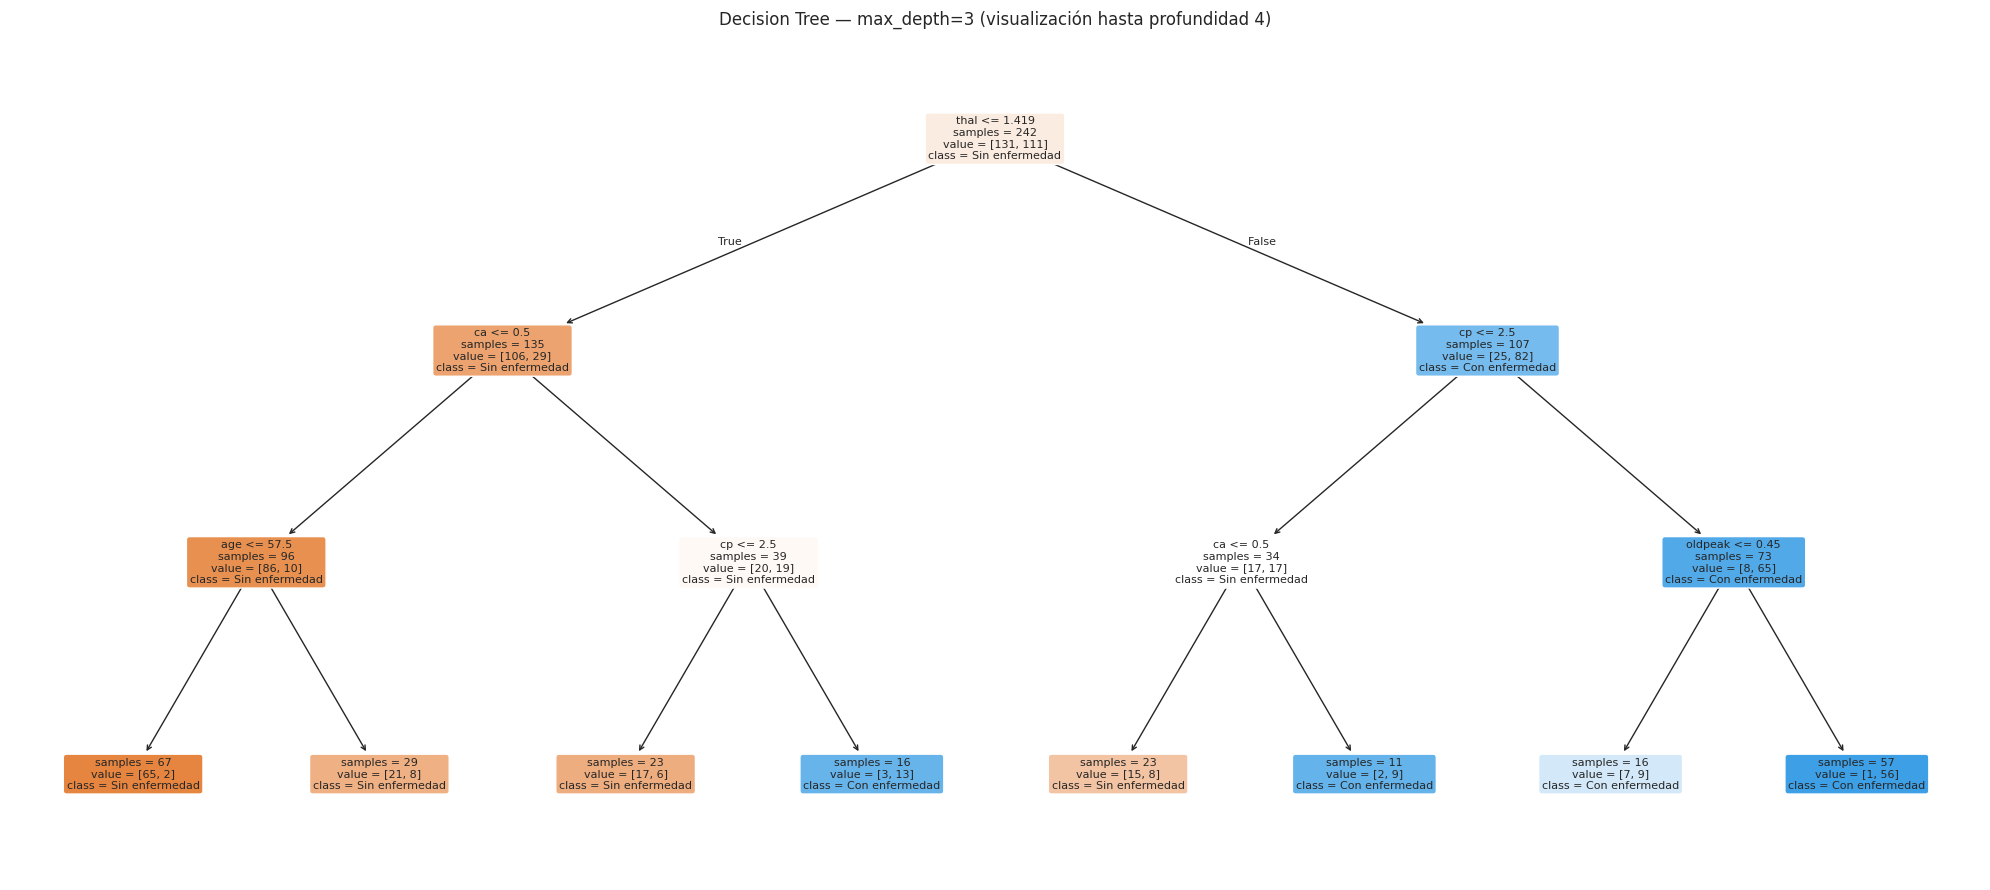

In [ ]:
# TODO 16: Visualizar el árbol con plot_tree (max_depth=4).
plt.figure(figsize=(20, 9))
plot_tree(
    dt_model,
    feature_names=FEATURE_COLS,
    class_names=['Sin enfermedad', 'Con enfermedad'],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8,
    impurity=False
)
plt.title(f'Decision Tree — max_depth={best_dt_depth} (visualización hasta profundidad 4)')
plt.tight_layout()
plt.show()


### 6.2 Random Forest Classifier


Random Forest
  Accuracy    : 0.8852
  F1          : 0.8852
  Precision   : 0.8912
  Recall      : 0.8912
  AUC-ROC     : 0.9421


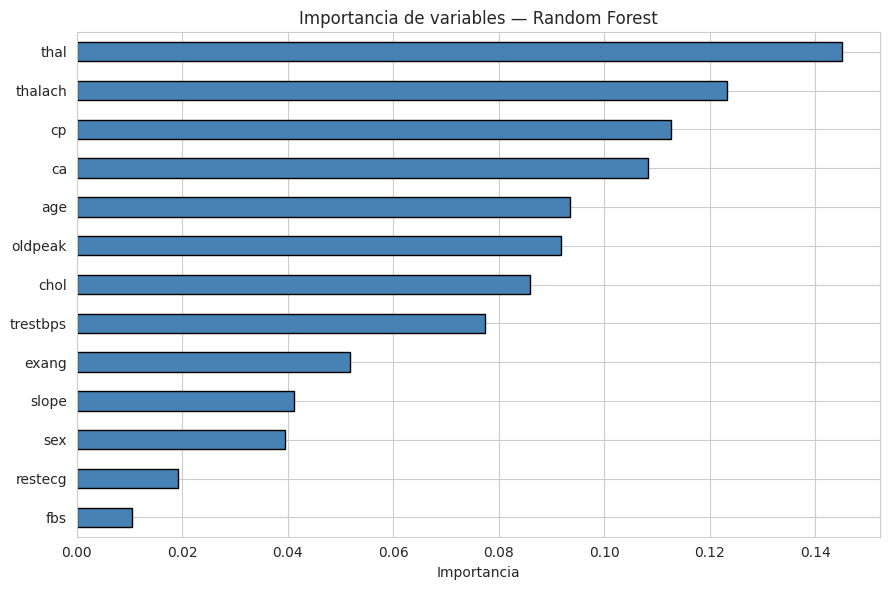


AUC Decision Tree: 0.8544
AUC Random Forest: 0.9421


In [ ]:
# TODO 17: Random Forest (n_estimators≥100). Graficar importancia de variables.
# Guardar en results_clf['RF'].
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)

results_clf['Random Forest'] = evaluar_modelo('Random Forest', y_test, rf_pred, rf_prob)
pred_store['Random Forest'] = {'pred': rf_pred, 'prob': rf_prob}
model_store['Random Forest'] = rf_model

# Importancia de variables, igual que en los ejemplos vistos en clase.
importancias = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
plt.figure(figsize=(9, 6))
importancias.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Importancia de variables — Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print(f"\nAUC Decision Tree: {results_clf['Decision Tree']['AUC-ROC']:.4f}")
print(f"AUC Random Forest: {results_clf['Random Forest']['AUC-ROC']:.4f}")


### 6.3 MLP Classifier (sklearn)

In [ ]:
# TODO 18: MLP — dos arquitecturas (64,32) y (128,64,32).
# Documentar efecto del solver (adam vs sgd) en comentarios.
# Guardar el mejor en results_clf['MLP'].
architectures = [(64, 32), (128, 64, 32)]
solvers = ['adam', 'sgd']
mlp_rows = []
mlp_candidates = {}

for architecture in architectures:
    for solver in solvers:
        model = MLPClassifier(
            hidden_layer_sizes=architecture,
            activation='relu',
            solver=solver,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=SEED
        )
        model.fit(X_train_s, y_train)

        pred = model.predict(X_test_s)
        prob = model.predict_proba(X_test_s)

        mlp_rows.append({
            'Arquitectura': str(architecture),
            'solver': solver,
            'Iteraciones': model.n_iter_,
            'Accuracy': accuracy_score(y_test, pred),
            'F1 macro': f1_score(y_test, pred, average='macro'),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred, zero_division=0),
            'AUC-ROC': roc_auc_score(y_test, prob[:, 1])
        })
        mlp_candidates[(architecture, solver)] = model

mlp_summary = pd.DataFrame(mlp_rows).sort_values('AUC-ROC', ascending=False)
display(mlp_summary.round(4).reset_index(drop=True))

best_mlp_row = mlp_summary.iloc[0]
best_arch = next(a for a in architectures if str(a) == best_mlp_row['Arquitectura'])
best_solver = best_mlp_row['solver']
mlp_model = mlp_candidates[(best_arch, best_solver)]
mlp_pred = mlp_model.predict(X_test_s)
mlp_prob = mlp_model.predict_proba(X_test_s)

results_clf['MLP'] = evaluar_modelo('MLP', y_test, mlp_pred, mlp_prob)
pred_store['MLP'] = {'pred': mlp_pred, 'prob': mlp_prob}
model_store['MLP'] = mlp_model

solver_comparison = mlp_summary.groupby('solver')[['AUC-ROC', 'Recall']].mean().round(4)
print('\nPromedio por solver en las dos arquitecturas:')
display(solver_comparison)
print(f'Mejor configuración MLP: arquitectura={best_arch}, solver={best_solver}.')
print('En este split, adam converge mejor que sgd con la configuración utilizada; el resultado depende también del escalado y de los hiperparámetros.')


,Arquitectura,solver,Iteraciones,Accuracy,F1 macro,Precision,Recall,AUC-ROC
0,"(128, 64, 32)",adam,29,0.8525,0.8499,0.8800,0.7857,0.9426
1,"(64, 32)",adam,19,0.8361,0.8360,0.7812,0.8929,0.9275
2,"(64, 32)",sgd,17,0.6393,0.6272,0.5682,0.8929,0.7900
3,"(128, 64, 32)",sgd,12,0.5410,0.3511,0.0000,0.0000,0.1916



MLP
  Accuracy    : 0.8525
  F1          : 0.8499
  Precision   : 0.8567
  Recall      : 0.8474
  AUC-ROC     : 0.9426

Promedio por solver en las dos arquitecturas:


,AUC-ROC,Recall
solver,,
adam,0.9351,0.8393
sgd,0.4908,0.4464


Mejor configuración MLP: arquitectura=(128, 64, 32), solver=adam.
En este split, adam converge mejor que sgd con la configuración utilizada; el resultado depende también del escalado y de los hiperparámetros.


## 7. Evaluación y comparación de modelos

In [ ]:
# TODO 19: Tabla comparativa ordenada por AUC-ROC.
comparison_clf = pd.DataFrame(results_clf.values()).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
display(comparison_clf)

best_name = comparison_clf.iloc[0]['Modelo']
worst_name = comparison_clf.iloc[-1]['Modelo']
print(f'\nMejor modelo por AUC-ROC: {best_name}')
print(f'Menor AUC-ROC: {worst_name}')


,Modelo,Accuracy,F1,Precision,Recall,AUC-ROC
0,MLP,0.8525,0.8499,0.8567,0.8474,0.9426
1,Random Forest,0.8852,0.8852,0.8912,0.8912,0.9421
2,Decision Tree,0.8525,0.8518,0.8513,0.8528,0.8544



Mejor modelo por AUC-ROC: MLP
Menor AUC-ROC: Decision Tree


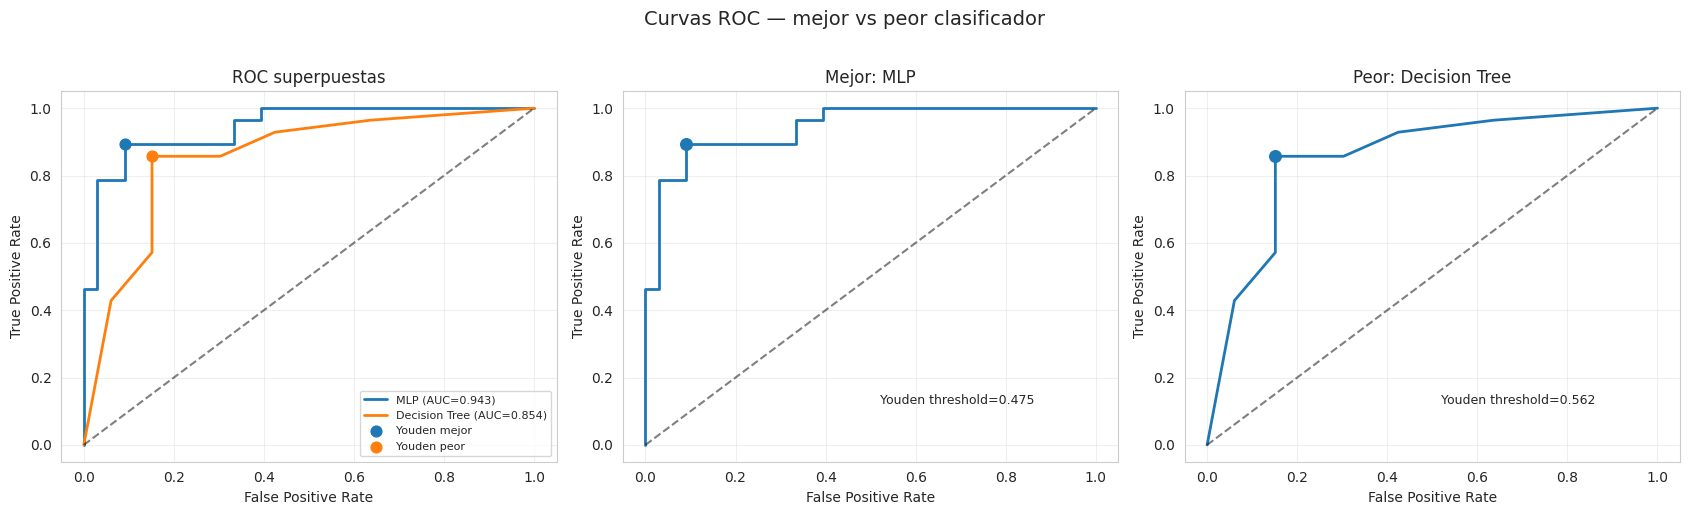

In [ ]:
# TODO 20: Curva ROC del mejor y peor modelo (superpuestas y en paneles separados).
# Marcar el punto óptimo de Youden.
def roc_youden(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    idx = np.argmax(tpr - fpr)
    return fpr, tpr, thresholds, idx

best_prob = pred_store[best_name]['prob'][:, 1]
worst_prob = pred_store[worst_name]['prob'][:, 1]

fpr_b, tpr_b, thr_b, idx_b = roc_youden(y_test, best_prob)
fpr_w, tpr_w, thr_w, idx_w = roc_youden(y_test, worst_prob)
auc_b = roc_auc_score(y_test, best_prob)
auc_w = roc_auc_score(y_test, worst_prob)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: curvas superpuestas.
axes[0].plot(fpr_b, tpr_b, linewidth=2, label=f'{best_name} (AUC={auc_b:.3f})')
axes[0].plot(fpr_w, tpr_w, linewidth=2, label=f'{worst_name} (AUC={auc_w:.3f})')
axes[0].scatter(fpr_b[idx_b], tpr_b[idx_b], s=60, label='Youden mejor')
axes[0].scatter(fpr_w[idx_w], tpr_w[idx_w], s=60, label='Youden peor')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC superpuestas')
axes[0].legend(fontsize=8)

# Panel 2: mejor modelo.
axes[1].plot(fpr_b, tpr_b, linewidth=2)
axes[1].scatter(fpr_b[idx_b], tpr_b[idx_b], s=70)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title(f'Mejor: {best_name}')
axes[1].text(0.52, 0.12, f'Youden threshold={thr_b[idx_b]:.3f}', fontsize=9)

# Panel 3: peor modelo.
axes[2].plot(fpr_w, tpr_w, linewidth=2)
axes[2].scatter(fpr_w[idx_w], tpr_w[idx_w], s=70)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[2].set_title(f'Peor: {worst_name}')
axes[2].text(0.52, 0.12, f'Youden threshold={thr_w[idx_w]:.3f}', fontsize=9)

for ax in axes:
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas ROC — mejor vs peor clasificador', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


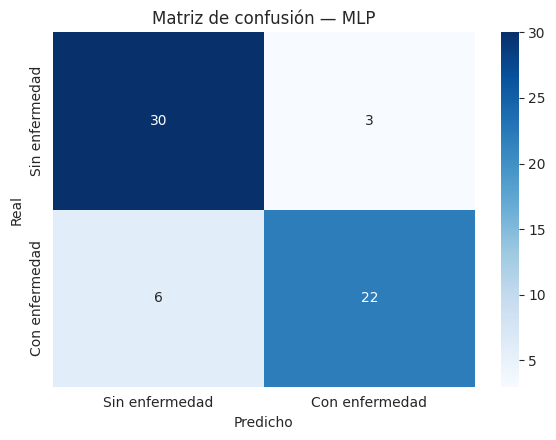

TN=30 | FP=3 | FN=6 | TP=22
Precision=0.880 | Recall=0.786

Interpretación clínica:
- Un falso negativo (FN) es especialmente costoso porque un paciente con enfermedad podría clasificarse como sano.
- Aumentar Recall ayuda a detectar más pacientes enfermos, aunque puede aumentar falsos positivos y reducir Precision.
- Por eso, en un contexto de tamizaje clínico normalmente se presta especial atención al Recall además del AUC-ROC.


In [ ]:
# TODO 21: Matriz de confusión del mejor modelo (heatmap seaborn).
# Interpretar: ¿cuál error es más costoso en contexto clínico?
best_pred = pred_store[best_name]['pred']
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin enfermedad', 'Con enfermedad'],
            yticklabels=['Sin enfermedad', 'Con enfermedad'])
plt.title(f'Matriz de confusión — {best_name}')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
precision_best = precision_score(y_test, best_pred, zero_division=0)
recall_best = recall_score(y_test, best_pred, zero_division=0)

print(f'TN={tn} | FP={fp} | FN={fn} | TP={tp}')
print(f'Precision={precision_best:.3f} | Recall={recall_best:.3f}')
print('\nInterpretación clínica:')
print('- Un falso negativo (FN) es especialmente costoso porque un paciente con enfermedad podría clasificarse como sano.')
print('- Aumentar Recall ayuda a detectar más pacientes enfermos, aunque puede aumentar falsos positivos y reducir Precision.')
print('- Por eso, en un contexto de tamizaje clínico normalmente se presta especial atención al Recall además del AUC-ROC.')



Fold 1: F1 macro = 0.8165
Fold 2: F1 macro = 0.7628
Fold 3: F1 macro = 0.8147
Fold 4: F1 macro = 0.7466
Fold 5: F1 macro = 0.8653

F1 macro promedio: 0.8012 ± 0.0424
Intervalo: [0.7588, 0.8436]


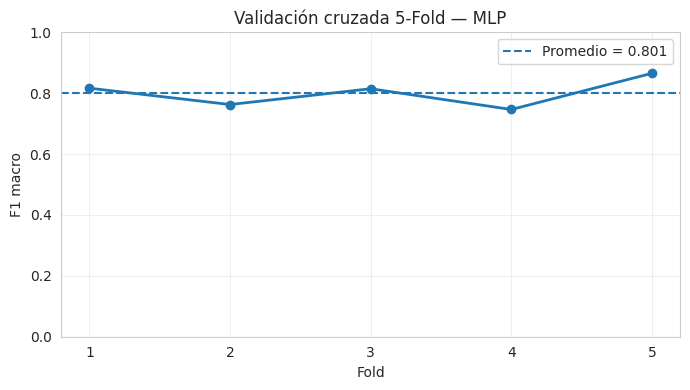

In [ ]:
# TODO 22: Validación cruzada 5-Fold con cross_val_score.
# Reportar F1 promedio ± std e intervalo. Graficar F1 por fold.

K = 5

# Crear los 5 folds manteniendo la proporción de las clases.
kf = StratifiedKFold(
    n_splits=K,
    shuffle=True,
    random_state=SEED
)

# Tomar el mejor modelo seleccionado anteriormente.
best_model = model_store[best_name]

# Incluir el preprocesamiento dentro del Pipeline.
# Así, en cada fold se vuelve a calcular la imputación y el escalado.
cv_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', best_model)
])

# Calcular F1 macro para cada uno de los 5 folds.
cv_scores = cross_val_score(
    cv_pipeline,
    X,
    y,
    cv=kf,
    scoring='f1_macro'
)

# Mostrar resultado de cada fold.
for i, score in enumerate(cv_scores):
    print(f'Fold {i+1}: F1 macro = {score:.4f}')

# Calcular promedio y desviación estándar.
f1_mean = cv_scores.mean()
f1_std = cv_scores.std()

# Intervalo alrededor de la media usando ± 1 desviación estándar.
limite_inferior = f1_mean - f1_std
limite_superior = f1_mean + f1_std

print(f'\nF1 macro promedio: {f1_mean:.4f} ± {f1_std:.4f}')
print(f'Intervalo: [{limite_inferior:.4f}, {limite_superior:.4f}]')

# Graficar F1 obtenido en cada fold.
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, K + 1),
    cv_scores,
    marker='o',
    linewidth=2
)

plt.axhline(
    f1_mean,
    linestyle='--',
    label=f'Promedio = {f1_mean:.3f}'
)

plt.xticks(range(1, K + 1))
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('F1 macro')
plt.title(f'Validación cruzada 5-Fold — {best_name}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# PARTE II — CLUSTERING: MALL CUSTOMERS

## 8. EDA del dataset de clustering

In [ ]:
df_mall = df_mall_raw.copy()
# _true_cluster se guarda aparte y se elimina del DataFrame de trabajo
#true_clusters = df_mall.pop('_true_cluster')

if '_true_cluster' in df_mall.columns:
    true_clusters = df_mall.pop('_true_cluster')
else:
    true_clusters = pd.Series(['PENDIENTE_ARCHIVO_OFICIAL'] * len(df_mall), index=df_mall.index)
    print('⚠️ _true_cluster no está en este CSV (dataset de prueba) — se usa un placeholder.')

print(f'Dimensiones: {df_mall.shape}')
display(df_mall.head(5))
print('\nNulos:', df_mall.isnull().sum().to_dict())

⚠️ _true_cluster no está en este CSV (dataset de prueba) — se usa un placeholder.
Dimensiones: (200, 5)


,CustomerID,Genre,Age,Annual_Income_k,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Nulos: {'CustomerID': 0, 'Genre': 0, 'Age': 0, 'Annual_Income_k': 0, 'Spending_Score': 0}


,Age,Annual_Income_k,Spending_Score
count,200.000,200.000,200.000
mean,38.850,60.560,50.200
std,13.969,26.265,25.824
min,18.000,15.000,1.000
25%,28.750,41.500,34.750
50%,36.000,61.500,50.000
75%,49.000,78.000,73.000
max,70.000,137.000,99.000


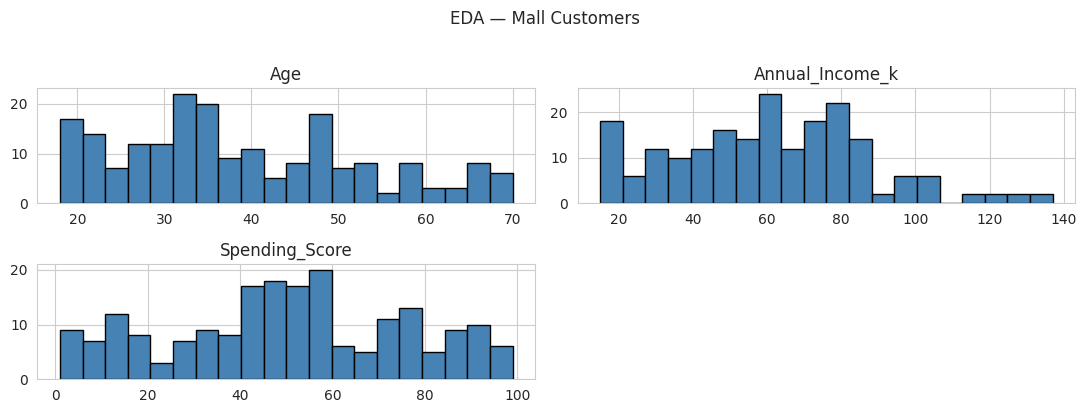

In [ ]:
SPEND_COLS = ['Age', 'Annual_Income_k', 'Spending_Score']

# Estadísticas descriptivas
display(df_mall[SPEND_COLS].describe().round(3))

# Distribución de Genre
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
genre_vc = df_mall['Genre'].value_counts()
axes[0].bar(genre_vc.index, genre_vc.values, color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Distribución por Género')
df_mall[SPEND_COLS].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='black')
plt.suptitle('EDA — Mall Customers', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

Mapeo de Genre: {'Female': np.int64(0), 'Male': np.int64(1)}


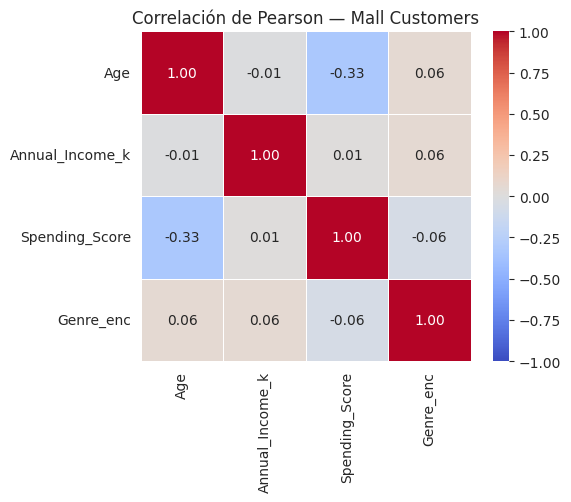


Skewness por variable:
Age                0.482
Annual_Income_k    0.319
Spending_Score    -0.047
dtype: float64

Ninguna variable numérica supera |skew|>0.75; no se aplica transformación log.


In [ ]:
# TODO 25: Codificar Genre con LabelEncoder. Mapa de calor de correlaciones. Skewness.
# 1) Codificar Genre (Male/Female) a numérico con LabelEncoder
le_genre = LabelEncoder()
df_mall['Genre_enc'] = le_genre.fit_transform(df_mall['Genre'])
print('Mapeo de Genre:', dict(zip(le_genre.classes_, le_genre.transform(le_genre.classes_))))

# 2) Mapa de calor de correlaciones de Pearson (numéricas + Genre codificado)
corr_cols = SPEND_COLS + ['Genre_enc']
corr_matrix = df_mall[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlación de Pearson — Mall Customers')
plt.tight_layout()
plt.show()

# 3) Skewness de las variables numéricas continuas
skew_vals = df_mall[SPEND_COLS].apply(skew).sort_values(key=abs, ascending=False)
print('\nSkewness por variable:')
print(skew_vals.round(3))

# 4) Aplicar log1p donde el sesgo es relevante (umbral |skew| > 0.75)
SKEW_THRESHOLD = 0.75
skewed_cols = skew_vals[skew_vals.abs() > SKEW_THRESHOLD].index.tolist()

if skewed_cols:
    print(f'\nVariables con sesgo relevante (|skew|>{SKEW_THRESHOLD}): {skewed_cols}')
    for col in skewed_cols:
        df_mall[f'{col}_log'] = np.log1p(df_mall[col])
        print(f'  {col}: skew original={skew_vals[col]:.3f}  ->  skew tras log1p={skew(df_mall[col + "_log"]):.3f}')
else:
    print(f'\nNinguna variable numérica supera |skew|>{SKEW_THRESHOLD}; no se aplica transformación log.')



       variable    Q1   Q3   IQR  limite_inf  limite_sup  n_outliers  %_outliers
            Age 28.75 49.0 20.25       -1.62       79.38           0         0.0
Annual_Income_k 41.50 78.0 36.50      -13.25      132.75           2         1.0
 Spending_Score 34.75 73.0 38.25      -22.62      130.38           0         0.0

Total registros con >=1 outlier: 2 (1.00%)


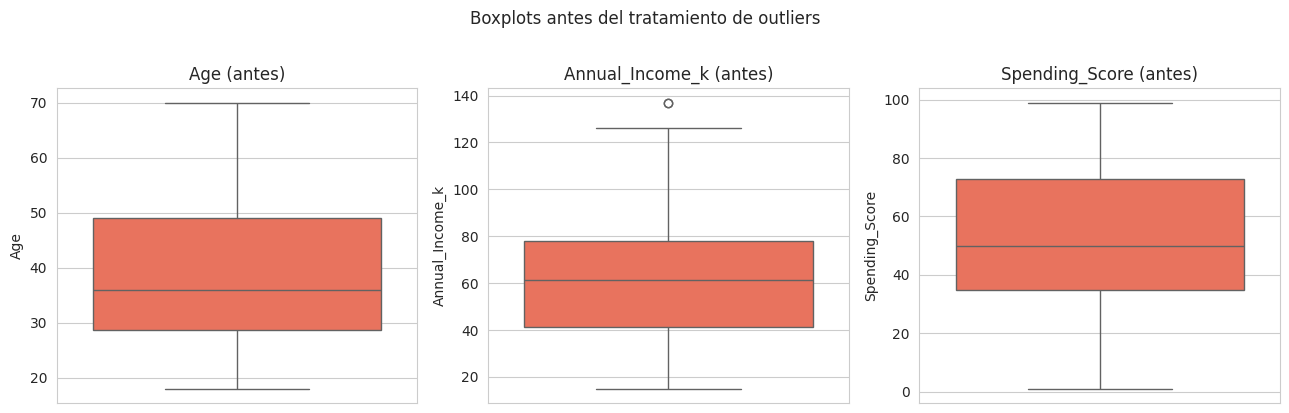


Filas originales: 200  ->  tras remover outliers: 198 (2 registros eliminados)


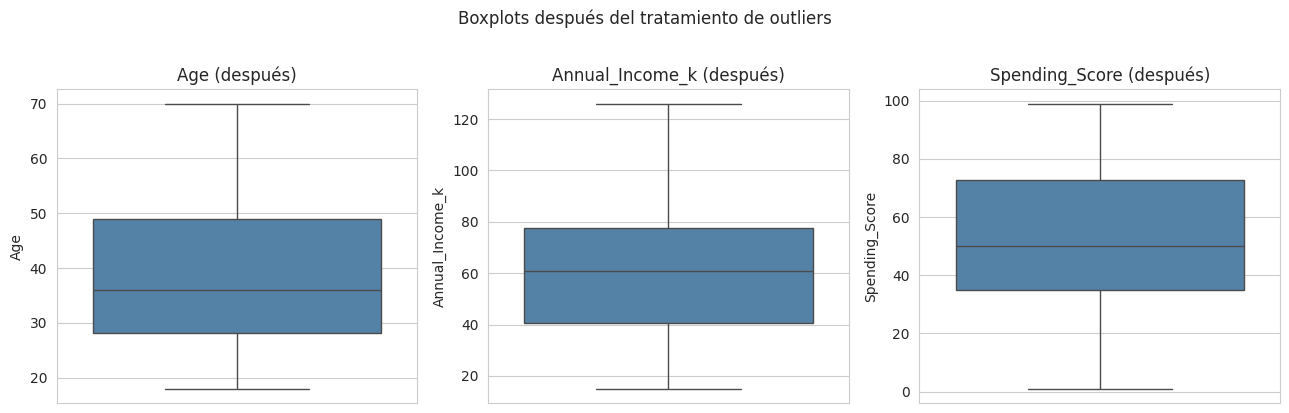

In [ ]:
# TODO 26: Outliers IQR sobre las variables de clustering.
# 1) Calcular Q1, Q3, IQR y límites por variable; cuantificar % de outliers por columna
outlier_summary = []
outlier_mask = pd.Series(False, index=df_mall.index)  # acumula outliers de cualquier variable

for col in SPEND_COLS:
    Q1, Q3 = df_mall[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    col_mask = (df_mall[col] < lower) | (df_mall[col] > upper)
    pct = 100 * col_mask.sum() / len(df_mall)
    outlier_summary.append({'variable': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
                             'IQR': round(IQR, 2), 'limite_inf': round(lower, 2),
                             'limite_sup': round(upper, 2), 'n_outliers': int(col_mask.sum()),
                             '%_outliers': round(pct, 2)})
    outlier_mask |= col_mask  # unión: la fila se marca si es outlier en AL MENOS una variable

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))
print(f"\nTotal registros con >=1 outlier: {outlier_mask.sum()} ({100*outlier_mask.sum()/len(df_mall):.2f}%)")

# 2) Boxplots ANTES del tratamiento
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, SPEND_COLS):
    sns.boxplot(y=df_mall[col], ax=ax, color='tomato')
    ax.set_title(f'{col} (antes)')
plt.suptitle('Boxplots antes del tratamiento de outliers', y=1.02)
plt.tight_layout()
plt.show()

# 3) Remoción de outliers — se preserva el índice original (necesario para alinear
#    df_mall_clean con true_clusters más adelante, en la sección de perfilado)
df_mall_clean = df_mall[~outlier_mask].copy()
print(f"\nFilas originales: {len(df_mall)}  ->  tras remover outliers: {len(df_mall_clean)} "
      f"({len(df_mall)-len(df_mall_clean)} registros eliminados)")

# 4) Boxplots DESPUÉS del tratamiento
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, SPEND_COLS):
    sns.boxplot(y=df_mall_clean[col], ax=ax, color='steelblue')
    ax.set_title(f'{col} (después)')
plt.suptitle('Boxplots después del tratamiento de outliers', y=1.02)
plt.tight_layout()
plt.show()


## 9. Preparación de features para clustering

In [ ]:
scaler_mall = StandardScaler()
X_mall = scaler_mall.fit_transform(df_mall_clean[SPEND_COLS])
print(f'Features escaladas: {X_mall.shape}')

# Índice de Hopkins
from sklearn.neighbors import NearestNeighbors
from random import sample as rnd_sample

def hopkins_index(X, m=None, seed=SEED):
    n, d = X.shape
    m = m or int(0.1*n)
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    rand_idx = rnd_sample(range(n), m)
    rng_h = np.random.default_rng(seed)
    ujd, wjd = [], []
    for j in range(m):
        u = rng_h.uniform(X.min(axis=0), X.max(axis=0), d).reshape(1,-1)
        ujd.append(nbrs.kneighbors(u, 2, return_distance=True)[0][0][1])
        wjd.append(nbrs.kneighbors(X[[rand_idx[j]]], 2, return_distance=True)[0][0][1])
    H = sum(ujd)/(sum(ujd)+sum(wjd))
    return round(float(H), 4)

H = hopkins_index(X_mall)
print(f'Índice de Hopkins: {H} ({"Apto para clustering" if H>0.7 else "Revisar estructura"})')

Features escaladas: (198, 3)
Índice de Hopkins: 0.7037 (Apto para clustering)


## 10. Selección de k — Elbow + Silhouette

  k= 2  Inercia=      385.28  Silhouette=0.3341
  k= 3  Inercia=      292.20  Silhouette=0.3564
  k= 4  Inercia=      202.70  Silhouette=0.4057
  k= 5  Inercia=      164.21  Silhouette=0.4212
  k= 6  Inercia=      128.64  Silhouette=0.4338
  k= 7  Inercia=      112.22  Silhouette=0.4243
  k= 8  Inercia=       98.95  Silhouette=0.4124
  k= 9  Inercia=       87.42  Silhouette=0.4210
  k=10  Inercia=       79.50  Silhouette=0.4233


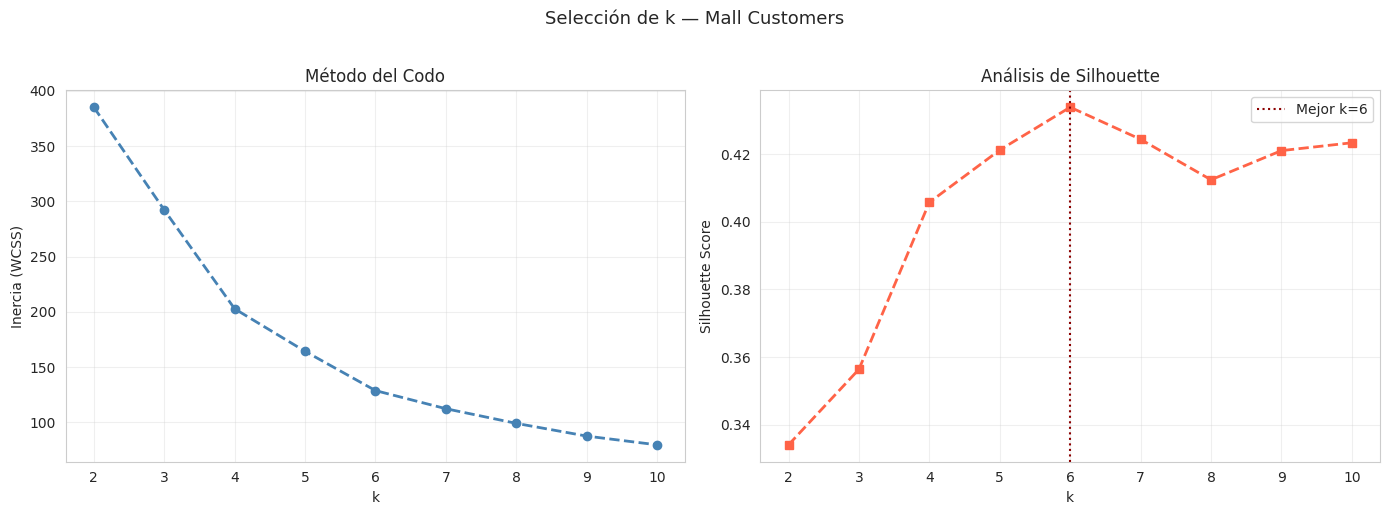

k seleccionado: 6


In [ ]:
K_RANGE = range(2, 11)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_mall)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_mall, labels, metric='euclidean'))
    print(f'  k={k:>2}  Inercia={inertias[-1]:>12,.2f}  Silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_RANGE), inertias, 'o--', color='steelblue', linewidth=2)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo'); axes[0].grid(alpha=0.3)

best_k = list(K_RANGE)[int(np.argmax(sil_scores))]
axes[1].plot(list(K_RANGE), sil_scores, 's--', color='tomato', linewidth=2)
axes[1].axvline(best_k, color='darkred', linestyle=':', label=f'Mejor k={best_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Análisis de Silhouette'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Selección de k — Mall Customers', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print(f'k seleccionado: {best_k}')
K_FINAL = best_k

## 11. Tres algoritmos de clustering

K-Means        | Silhouette=0.4338 | tamaños={0: 45, 1: 38, 2: 32, 3: 21, 4: 38, 5: 24}
  Agglomerative (ward    ) | Silhouette=0.4259
  Agglomerative (complete) | Silhouette=0.3460
  Agglomerative (average ) | Silhouette=0.3946
-> Mejor linkage: ward (Silhouette=0.4259)


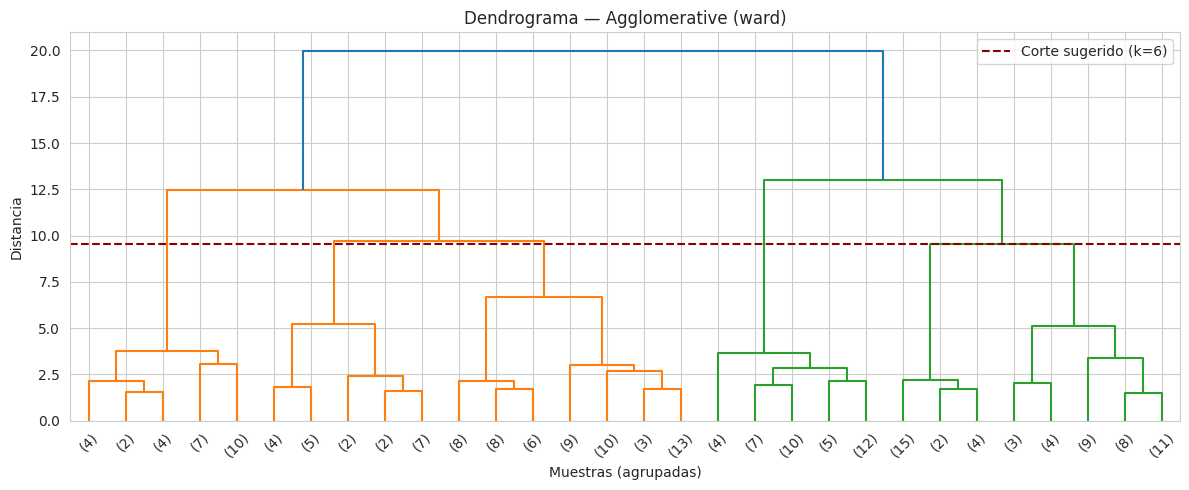

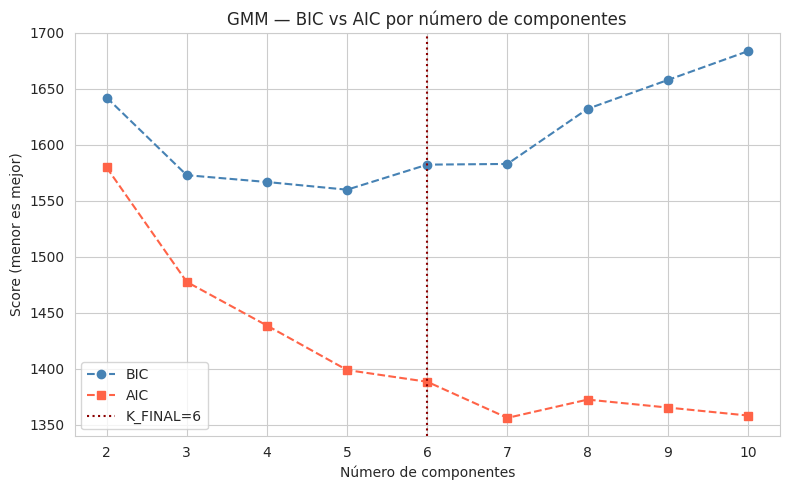

Mejor k según BIC=5  |  según AIC=7  |  K_FINAL usado (consistencia con los otros 2 algoritmos)=6
GMM            | Silhouette=0.4209 | tamaños={0: 33, 1: 52, 2: 38, 3: 32, 4: 23, 5: 20}

Resumen — Silhouette Score por algoritmo:
    Algoritmo  Silhouette
      K-Means      0.4338
Agglomerative      0.4259
          GMM      0.4209


In [ ]:
# TODO 29: Entrenar K-Means, AgglomerativeClustering y GMM con K_FINAL.
# Para Agglomerative: probar linkage=ward/complete/average. Dendrograma.
# Para GMM: graficar BIC vs AIC. Reportar Silhouette de los tres.
results_clust = {}

# 1) K-Means -----------------------------------------------------------------
km_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
labels_km = km_final.fit_predict(X_mall)
sil_km = silhouette_score(X_mall, labels_km)
sizes_km = pd.Series(labels_km).value_counts().sort_index().to_dict()
results_clust['K-Means'] = {'Silhouette': sil_km, 'sizes': sizes_km}
print(f'K-Means        | Silhouette={sil_km:.4f} | tamaños={sizes_km}')

# 2) AgglomerativeClustering — comparar linkage ward / complete / average ----
linkage_results = {}
for link in ['ward', 'complete', 'average']:
    agg = AgglomerativeClustering(n_clusters=K_FINAL, linkage=link)
    lbl = agg.fit_predict(X_mall)
    sil = silhouette_score(X_mall, lbl)
    linkage_results[link] = {'labels': lbl, 'Silhouette': sil}
    print(f'  Agglomerative ({link:<8}) | Silhouette={sil:.4f}')

# Se elige el linkage con mejor Silhouette para representar al algoritmo
best_linkage = max(linkage_results, key=lambda l: linkage_results[l]['Silhouette'])
labels_agg = linkage_results[best_linkage]['labels']
sil_agg = linkage_results[best_linkage]['Silhouette']
sizes_agg = pd.Series(labels_agg).value_counts().sort_index().to_dict()
results_clust['Agglomerative'] = {'Silhouette': sil_agg, 'sizes': sizes_agg, 'linkage': best_linkage}
print(f'-> Mejor linkage: {best_linkage} (Silhouette={sil_agg:.4f})')

# Dendrograma con el mejor linkage; se trunca a los últimos 30 merges para legibilidad
Z = linkage(X_mall, method=best_linkage)
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30, ax=ax)
ax.axhline(y=Z[-(K_FINAL - 1), 2], color='darkred', linestyle='--',
           label=f'Corte sugerido (k={K_FINAL})')
ax.set_title(f'Dendrograma — Agglomerative ({best_linkage})')
ax.set_xlabel('Muestras (agrupadas)'); ax.set_ylabel('Distancia')
ax.legend()
plt.tight_layout()
plt.show()

# 3) Gaussian Mixture Model ----------------------------------------------------
# BIC/AIC en un rango de componentes: valida de forma independiente si K_FINAL
# (elegido antes por Elbow+Silhouette) es también razonable para un modelo GMM
gmm_range = range(2, 11)
bic_scores, aic_scores = [], []
for k in gmm_range:
    gmm_k = GaussianMixture(n_components=k, random_state=SEED, n_init=10)
    gmm_k.fit(X_mall)
    bic_scores.append(gmm_k.bic(X_mall))
    aic_scores.append(gmm_k.aic(X_mall))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(gmm_range), bic_scores, 'o--', label='BIC', color='steelblue')
ax.plot(list(gmm_range), aic_scores, 's--', label='AIC', color='tomato')
ax.axvline(K_FINAL, color='darkred', linestyle=':', label=f'K_FINAL={K_FINAL}')
ax.set_xlabel('Número de componentes'); ax.set_ylabel('Score (menor es mejor)')
ax.set_title('GMM — BIC vs AIC por número de componentes')
ax.legend()
plt.tight_layout()
plt.show()

k_bic = list(gmm_range)[int(np.argmin(bic_scores))]
k_aic = list(gmm_range)[int(np.argmin(aic_scores))]
print(f'Mejor k según BIC={k_bic}  |  según AIC={k_aic}  |  K_FINAL usado (consistencia con los otros 2 algoritmos)={K_FINAL}')

# Modelo final con K_FINAL, para comparar los 3 algoritmos en igualdad de condiciones
gmm_final = GaussianMixture(n_components=K_FINAL, random_state=SEED, n_init=10)
labels_gmm = gmm_final.fit_predict(X_mall)
sil_gmm = silhouette_score(X_mall, labels_gmm)
sizes_gmm = pd.Series(labels_gmm).value_counts().sort_index().to_dict()
results_clust['GMM'] = {'Silhouette': sil_gmm, 'sizes': sizes_gmm,
                         'BIC': gmm_final.bic(X_mall), 'AIC': gmm_final.aic(X_mall)}
print(f'GMM            | Silhouette={sil_gmm:.4f} | tamaños={sizes_gmm}')

# Resumen comparativo de los 3 algoritmos
resumen_clust = pd.DataFrame({
    'Algoritmo': list(results_clust.keys()),
    'Silhouette': [round(results_clust[k]['Silhouette'], 4) for k in results_clust]
}).sort_values('Silhouette', ascending=False)
print('\nResumen — Silhouette Score por algoritmo:')
print(resumen_clust.to_string(index=False))


## 12. Visualización con TSNE (PCA previo)

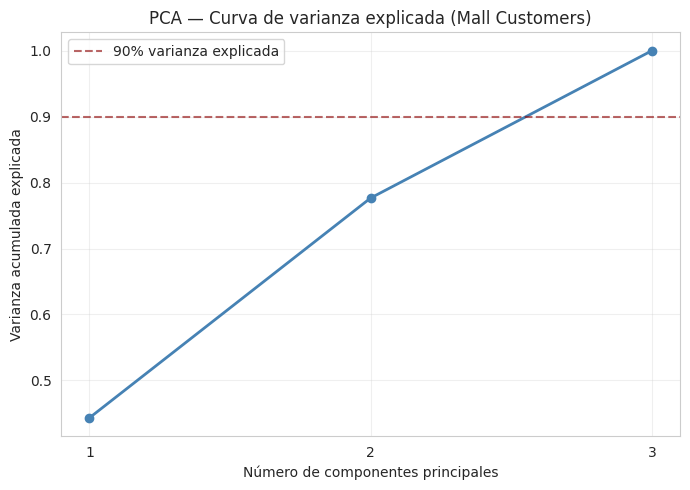

Varianza explicada por componente: [0.4432 0.3334 0.2234]
Varianza acumulada: [0.4432 0.7766 1.    ]

Con 2 componentes se retiene 77.7% de la varianza.
TSNE calculado: (198, 2)


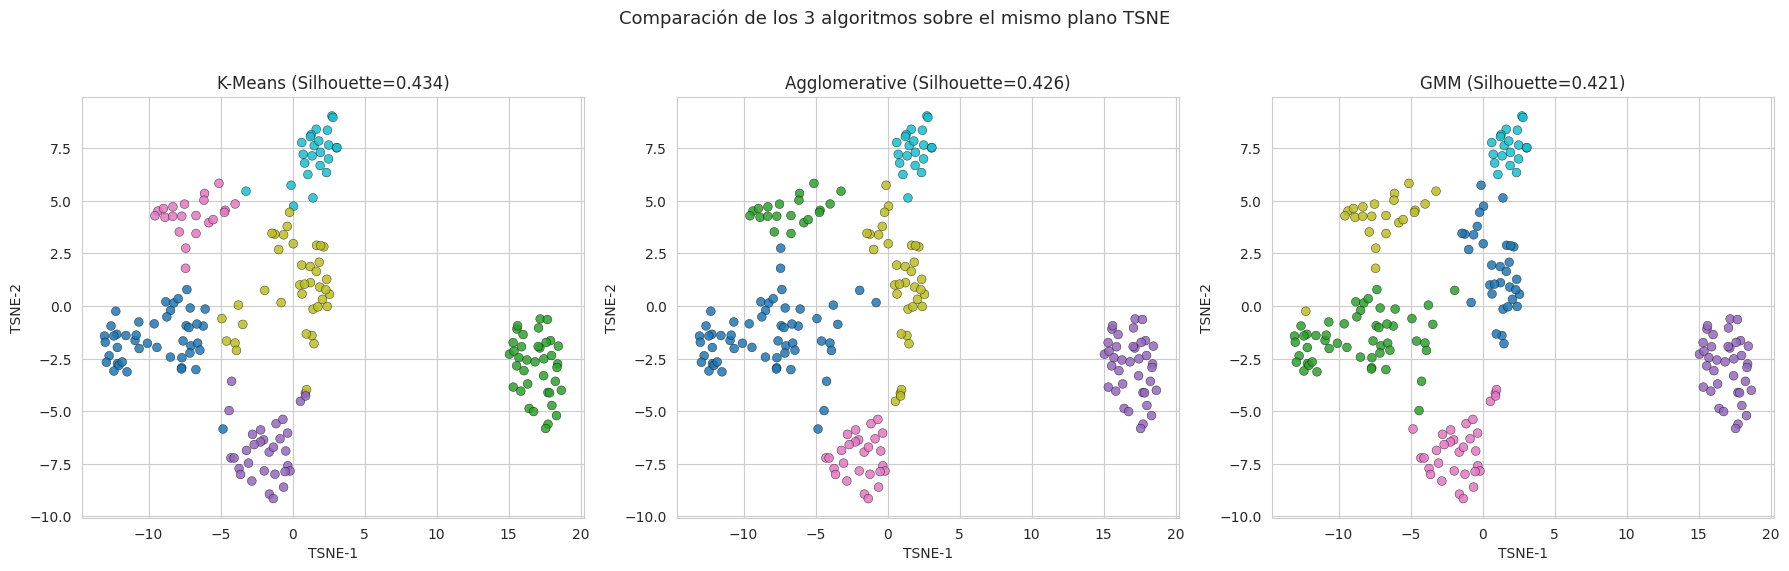

In [ ]:
# TODO 30: PCA (curva de varianza) + TSNE. Graficar 3 paneles comparativos.
# 1) PCA — curva de varianza explicada, para justificar cuántos componentes usar
pca_full = PCA(n_components=X_mall.shape[1], random_state=SEED)  # todos los componentes posibles (3)
pca_full.fit(X_mall)
var_ratio = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_ratio)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(range(1, len(var_ratio) + 1), var_cum, 'o-', color='steelblue', linewidth=2)
ax.axhline(0.90, color='darkred', linestyle='--', alpha=0.6, label='90% varianza explicada')
ax.set_xlabel('Número de componentes principales'); ax.set_ylabel('Varianza acumulada explicada')
ax.set_title('PCA — Curva de varianza explicada (Mall Customers)')
ax.set_xticks(range(1, len(var_ratio) + 1))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Varianza explicada por componente:', np.round(var_ratio, 4))
print('Varianza acumulada:', np.round(var_cum, 4))

# Justificación: con solo 3 variables originales, PCA no busca "reducir muchas
# dimensiones" sino dar una proyección lineal 2D interpretable. Se eligen 2
# componentes porque permiten graficar en 2D y retienen la mayoría de la varianza.
N_COMPONENTS_PCA = 2
pca = PCA(n_components=N_COMPONENTS_PCA, random_state=SEED)
X_pca = pca.fit_transform(X_mall)
print(f'\nCon {N_COMPONENTS_PCA} componentes se retiene {var_cum[N_COMPONENTS_PCA-1]*100:.1f}% de la varianza.')

# 2) TSNE — embedding 2D no lineal, calculado sobre las variables escaladas originales
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init='pca')
X_tsne = tsne.fit_transform(X_mall)
print(f'TSNE calculado: {X_tsne.shape}')

# 3) Graficar los 3 algoritmos sobre EL MISMO plano TSNE (3 paneles comparativos)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
algoritmos_labels = {'K-Means': labels_km, 'Agglomerative': labels_agg, 'GMM': labels_gmm}

for ax, (nombre, lbl) in zip(axes, algoritmos_labels.items()):
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=lbl, cmap='tab10', s=40,
               edgecolor='black', linewidth=0.3, alpha=0.85)
    sil = results_clust[nombre]['Silhouette']
    ax.set_title(f'{nombre} (Silhouette={sil:.3f})')
    ax.set_xlabel('TSNE-1'); ax.set_ylabel('TSNE-2')

plt.suptitle('Comparación de los 3 algoritmos sobre el mismo plano TSNE', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


In [ ]:
# COMPLETAR: ver enunciado
# Tu código aquí:


## 13. Perfilado e interpretación de clusters

In [ ]:
# Mejor algoritmo por Silhouette
best_alg = max(results_clust, key=lambda k: results_clust[k]['Silhouette'])
best_labels = {'K-Means': labels_km, 'Agglomerative': labels_agg, 'GMM': labels_gmm}[best_alg]
print(f'Mejor algoritmo: {best_alg}')

df_mall_clean['cluster'] = best_labels

# Perfil en escala original
profile = (df_mall_clean.groupby('cluster')[SPEND_COLS]
           .mean().round(2))
profile['n_clientes'] = df_mall_clean.groupby('cluster').size()
print('\nPerfil de clusters:')
display(profile)

Mejor algoritmo: K-Means

Perfil de clusters:


,Age,Annual_Income_k,Spending_Score,n_clientes
cluster,,,,
0,56.33,54.27,49.07,45
1,32.76,85.21,82.11,38
2,42.25,87.44,16.94,32
3,45.52,26.29,19.38,21
4,26.68,57.58,47.79,38
5,25.25,25.83,76.92,24


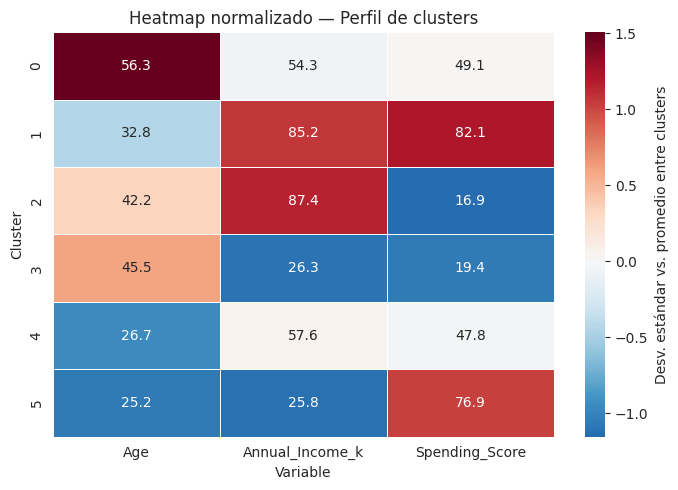

Tabla cruzada — clusters encontrados vs. _true_cluster:


_true_cluster,PENDIENTE_ARCHIVO_OFICIAL
Cluster (K-Means),
0,45
1,38
2,32
3,21
4,38
5,24


Cluster 0: 'Clientes Estándar'
   Justificación: ingreso anual medio ($54k), gasto medio (49/100), edad promedio 56 años, 45 clientes.
Cluster 1: 'Clientes Premium'
   Justificación: ingreso anual alto ($85k), gasto alto (82/100), edad promedio 33 años, 38 clientes.
Cluster 2: 'Clientes Cautelosos'
   Justificación: ingreso anual alto ($87k), gasto bajo (17/100), edad promedio 42 años, 32 clientes.
Cluster 3: 'Clientes de Bajo Valor'
   Justificación: ingreso anual bajo ($26k), gasto bajo (19/100), edad promedio 46 años, 21 clientes.
Cluster 4: 'Clientes Estándar'
   Justificación: ingreso anual medio ($58k), gasto medio (48/100), edad promedio 27 años, 38 clientes.
Cluster 5: 'Clientes Objetivo (bajo ingreso, alto gasto)'
   Justificación: ingreso anual bajo ($26k), gasto alto (77/100), edad promedio 25 años, 24 clientes.

Perfil final con nombres de negocio:


,Age,Annual_Income_k,Spending_Score,n_clientes,nombre_negocio
cluster,,,,,
0,56.33,54.27,49.07,45,Clientes Estándar
1,32.76,85.21,82.11,38,Clientes Premium
2,42.25,87.44,16.94,32,Clientes Cautelosos
3,45.52,26.29,19.38,21,Clientes de Bajo Valor
4,26.68,57.58,47.79,38,Clientes Estándar
5,25.25,25.83,76.92,24,"Clientes Objetivo (bajo ingreso, alto gasto)"


In [ ]:
# COMPLETAR: ver enunciado
# 1) Heatmap normalizado del perfil de clusters (z-score de cada variable ENTRE clusters)
profile_z = (profile[SPEND_COLS] - profile[SPEND_COLS].mean()) / profile[SPEND_COLS].std()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(profile_z, annot=profile[SPEND_COLS].round(1), fmt='.1f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Desv. estándar vs. promedio entre clusters'})
ax.set_title('Heatmap normalizado — Perfil de clusters')
ax.set_xlabel('Variable'); ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

# 2) Tabla cruzada: clusters encontrados vs _true_cluster (SOLO para validar; no se usó en el clustering)
# Se alinea por índice porque df_mall_clean tiene menos filas que el dataset original
# (se removieron outliers en la celda 42, conservando el índice original a propósito)
true_clusters_aligned = true_clusters.loc[df_mall_clean.index]
crosstab = pd.crosstab(df_mall_clean['cluster'], true_clusters_aligned,
                        rownames=[f'Cluster ({best_alg})'], colnames=['_true_cluster'])
print('Tabla cruzada — clusters encontrados vs. _true_cluster:')
display(crosstab)

# 3) Asignar nombre de negocio a cada cluster, según terciles de Income y Spending Score
income_terciles = profile['Annual_Income_k'].quantile([1/3, 2/3]).values
spend_terciles = profile['Spending_Score'].quantile([1/3, 2/3]).values

# Clasifica un valor como Alto/Medio/Bajo según terciles calculados ENTRE los clusters
def nivel(valor, terciles):
    if valor >= terciles[1]:
        return 'Alto'
    if valor <= terciles[0]:
        return 'Bajo'
    return 'Medio'

NOMBRES_NEGOCIO = {
    ('Alto', 'Alto'): 'Clientes Premium',
    ('Alto', 'Medio'): 'Clientes Premium Moderados',
    ('Alto', 'Bajo'): 'Clientes Cautelosos',
    ('Medio', 'Alto'): 'Clientes Entusiastas',
    ('Medio', 'Medio'): 'Clientes Estándar',
    ('Medio', 'Bajo'): 'Clientes Conservadores',
    ('Bajo', 'Alto'): 'Clientes Objetivo (bajo ingreso, alto gasto)',
    ('Bajo', 'Medio'): 'Clientes Ajustados',
    ('Bajo', 'Bajo'): 'Clientes de Bajo Valor',
}

nombres_clusters = {}
for cl in profile.index:
    inc_lvl = nivel(profile.loc[cl, 'Annual_Income_k'], income_terciles)
    spd_lvl = nivel(profile.loc[cl, 'Spending_Score'], spend_terciles)
    nombre = NOMBRES_NEGOCIO[(inc_lvl, spd_lvl)]
    nombres_clusters[cl] = nombre
    print(f"Cluster {cl}: '{nombre}'")
    print(f"   Justificación: ingreso anual {inc_lvl.lower()} (${profile.loc[cl,'Annual_Income_k']:.0f}k), "
          f"gasto {spd_lvl.lower()} ({profile.loc[cl,'Spending_Score']:.0f}/100), "
          f"edad promedio {profile.loc[cl,'Age']:.0f} años, {int(profile.loc[cl,'n_clientes'])} clientes.")

profile['nombre_negocio'] = profile.index.map(nombres_clusters)
print('\nPerfil final con nombres de negocio:')
display(profile)
